<a href="https://colab.research.google.com/github/traviswheeler/CompBioAsia/blob/main/CompBioGNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Setup


In [ ]:
!pip install torch torch_geometric

import torch
from torch_geometric.data import Data

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("torch", torch.__version__, "| device:", device)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 26.5 MB/s eta 0:00:00
torch 2.11.0+cu128 | device: cuda


## 1. The `Data` object

In PyG a graph is just a `Data` object holding a few tensors. Two of them carry everything:

- **`x`** — node features, shape `[num_nodes, num_node_features]`. One row = one node's feature vector.
- **`edge_index`** — connectivity in COO format, shape `[2, num_edges]`. Column `[i, j]` means *an edge from node i to node j*. Edges are directed, so for an **undirected** graph you list both directions.

Optional extras: `edge_attr` (a feature vector per edge — e.g. bond type), `y` (a label, per-node or per-graph), `pos` (coordinates).

Let's build the six-node graph from the slides by hand.

Data(x=[6, 3], edge_index=[2, 14], y=[1])
nodes: 6 | edges: 14 | features/node: 3 | undirected: True


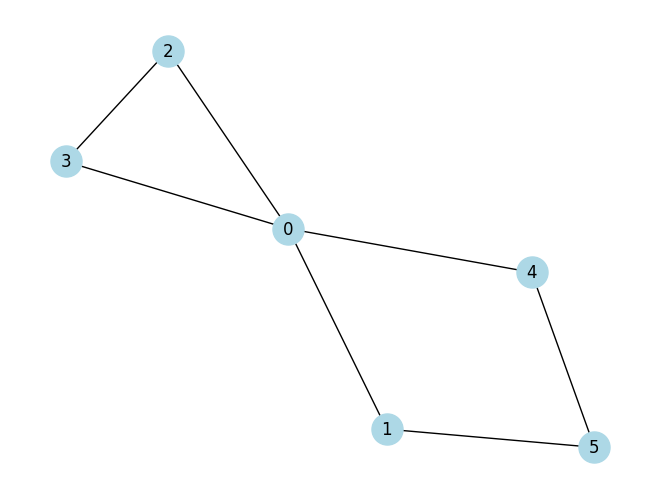

In [ ]:
# node features: a vector per node.
x = torch.tensor([
    [1.0, 0.0, 0.0],   # node 0
    [0.0, 1.0, 0.0],   # node 1
    [0.0, 1.0, 0.0],   # node 2
    [0.0, 1.0, 0.0],   # node 3
    [0.0, 1.0, 0.0],   # node 4
    [0.0, 0.0, 1.0],   # node 5
], dtype=torch.float)

# edges (undirected -> list each one in BOTH directions).
# 0-1, 0-2, 0-3, 0-4, 1-5, 4-5, 2-3
edge_index = torch.tensor([
    [0, 1, 0, 2, 0, 3, 0, 4, 1, 5, 4, 5, 2, 3],
    [1, 0, 2, 0, 3, 0, 4, 0, 5, 1, 5, 4, 3, 2],
], dtype=torch.long)

y = torch.tensor([0])  # a single graph-level label

data = Data(x=x, edge_index=edge_index, y=y)
print(data)
print("nodes:", data.num_nodes, "| edges:", data.num_edges,
      "| features/node:", data.num_node_features, "| undirected:", data.is_undirected())

# visualize gaph
from torch_geometric.utils import to_networkx
import networkx as nx
import matplotlib.pyplot as plt

G = to_networkx(data, to_undirected=True)
nx.draw(G, with_labels=True, node_color='lightblue', node_size=500)
plt.show()

### See message passing happen on this graph

A conv layer takes `(x, edge_index)` and returns a **new** vector per node that has mixed in its neighbors. Nothing else changes — same number of nodes, new embeddings.

In [ ]:
from torch_geometric.nn import GCNConv

demo_conv = GCNConv(in_channels=3, out_channels=8)
h = demo_conv(data.x, data.edge_index)

print("in :", data.x.shape)   # [6, 3]  -> one 3-dim vector per node
print("out:", h.shape)        # [6, 8]  -> one 8-dim *learned* vector per node

in : torch.Size([6, 3])
out: torch.Size([6, 8])


### Using this for your own data

Everything downstream, consumes `Data` objects. To bring your own data you just fill in the tensors:

- nodes → rows of `x`
- edges → columns of `edge_index` (both directions if undirected)
- edge features (optional) → `edge_attr`
- labels → `y`


## 2. A real dataset: NCI1

NCI1 is a standard graph-classification benchmark: ~4,100 molecule graphs from anti-cancer screening, each labeled active or inactive. Nodes are atoms (one-hot atom type); edges are bonds. It's a graph-level task — one label per whole graph — which is why we need pooling later.

Each item is the same `Data` class we built by hand.


In [ ]:
from torch_geometric.datasets import TUDataset

dataset = TUDataset(root='data/TUDataset', name='NCI1')
dataset = dataset.shuffle()   # shuffle once so the split below is balanced

print(dataset)
print("graphs:", len(dataset),
      "| features/node:", dataset.num_node_features,
      "| classes:", dataset.num_classes)

print("\nFirst graph:", dataset[0])

### Class balance




In [ ]:
y_all = torch.cat([data.y for data in dataset])
counts = torch.bincount(y_all)
total = counts.sum().item()

for cls, c in enumerate(counts.tolist()):
    print(f"class {cls}: {c:4d}  ({c / total:.1%})")

majority = counts.max().item() / total
print(f"\nmajority-class baseline accuracy: {majority:.1%}")


## 3. Batching: how PyG handles variable-size graphs

Graphs have different numbers of nodes, so you can't just stack them like images. PyG's `DataLoader` instead glues a batch of graphs into **one big disconnected graph**, and adds a `batch` vector that records which graph each node came from. That `batch` vector is what pooling uses later to collapse nodes back down to one vector *per graph*.

In [ ]:
from torch_geometric.loader import DataLoader

n = len(dataset)
split = int(0.8 * n)
train_dataset = dataset[:split]
test_dataset  = dataset[split:]
print(f"train: {len(train_dataset)} | test: {len(test_dataset)}")

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=128)

batch = next(iter(train_loader))
print(batch)                       # note the extra `batch` attribute
print("graphs in this batch:", batch.num_graphs)

## 4. A basic model

The model is the three-step skeleton, twice, then a readout:

1. **conv1, conv2** — each does message → aggregate → update internally
2. **`global_mean_pool`** — the readout: average all node embeddings into one vector *per graph* (pooling is just aggregation again, run over the whole graph)
3. **`Linear`** — classify that graph vector

Notice the model takes the **conv layer as an argument**. That's the whole trick — it's what lets us swap architectures without touching anything else.

In [ ]:
import torch.nn.functional as F
from torch.nn import Linear
from torch_geometric.nn import GCNConv, GATConv, global_mean_pool


class GNN(torch.nn.Module):
    def __init__(self, conv_layer, in_channels, hidden_channels, num_classes):
        super().__init__()
        self.conv1 = conv_layer(in_channels, hidden_channels)
        self.conv2 = conv_layer(hidden_channels, hidden_channels)

        self.classifier = Linear(hidden_channels, num_classes)

    def forward(self, x, edge_index, batch):
        # message -> aggregate -> update, twice
        x = self.conv1(x, edge_index).relu()
        x = self.conv2(x, edge_index).relu()
        # readout: node embeddings -> one vector per graph
        x = global_mean_pool(x, batch)
        x = F.dropout(x, p=0.3, training=self.training)

        # classify
        return self.classifier(x)

### Build a GCN

GCN's aggregate step is a **normalized mean** of the neighbors. We pick it by passing `GCNConv`.

In [ ]:
gcn = GNN(GCNConv,
          in_channels=dataset.num_node_features,
          hidden_channels=64,
          num_classes=dataset.num_classes)
print(gcn)

## 5. GCN → GAT

To turn this GCN into a Graph Attention Network, we change: `GCNConv` → `GATConv`.

Why it works: every PyG conv obeys the same `(x, edge_index) -> x` interface (they all inherit from the `MessagePassing` base class). Only the aggregate step differs:

- **GCN**: weight every neighbor equally (normalized mean)
- **GAT**: *learn* how much each neighbor matters (attention-weighted sum)


In [ ]:
gat = GNN(GATConv,
          in_channels=dataset.num_node_features,
          hidden_channels=64,
          num_classes=dataset.num_classes)
print(gat)

Side by side: the only thing that changed is the layer type

In [ ]:
for ConvLayer in (GCNConv, GATConv):
    model = GNN(ConvLayer,
                dataset.num_node_features,
                hidden_channels=64,
                num_classes=dataset.num_classes)
    print(f"{ConvLayer.__name__:>10}  ->  conv1 = {model.conv1}")

## 6. Train and evaluate

Standard PyTorch loop. The only GNN-specific bit is passing `data.batch` so pooling knows which nodes belong to which graph. Batches and the model are moved to `device`, so this uses the GPU automatically on Colab. We track the loss each epoch and print it as training goes.


In [ ]:
def train(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for data in loader:
        data = data.to(device)
        optimizer.zero_grad()
        out = model(data.x, data.edge_index, data.batch)
        loss = criterion(out, data.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * data.num_graphs
    return total_loss / len(loader.dataset)   # avg loss per graph this epoch


@torch.no_grad()
def test(model, loader):
    model.eval()
    correct = 0
    for data in loader:
        data = data.to(device)
        out = model(data.x, data.edge_index, data.batch)
        pred = out.argmax(dim=1)
        correct += int((pred == data.y).sum())
    return correct / len(loader.dataset)


def run(ConvLayer, epochs=150, verbose=True):
    model = GNN(ConvLayer, dataset.num_node_features, 64, dataset.num_classes).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.005)
    criterion = torch.nn.CrossEntropyLoss()
    history = {"loss": [], "train": [], "test": []}
    for epoch in range(1, epochs + 1):
        loss = train(model, train_loader, optimizer, criterion)
        tr, te = test(model, train_loader), test(model, test_loader)
        history["loss"].append(loss)
        history["train"].append(tr)
        history["test"].append(te)
        if verbose and epoch % 20 == 0:
            print(f"epoch {epoch:3d} | loss {loss:.4f} | train {tr:.3f} | test {te:.3f}")
    return model, history


In [ ]:
gcn_model, gcn_hist = run(GCNConv)

In [ ]:
gat_model, gat_hist = run(GATConv)

### Training loss



In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(gcn_hist["loss"], label="GCN")
plt.plot(gat_hist["loss"], label="GAT")
plt.xlabel("epoch")
plt.ylabel("training loss")
plt.title("Training loss")
plt.legend()
plt.tight_layout()
plt.show()


# ROC AUC curve

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score


@torch.no_grad()
def predict_proba(model, loader):
    """Return (true labels, predicted probability of class 1) over a loader."""
    model.eval()
    ys, scores = [], []
    for data in loader:
        data = data.to(device)
        out = model(data.x, data.edge_index, data.batch)
        prob = F.softmax(out, dim=1)[:, 1]   # P(class = 1)
        ys.append(data.y)
        scores.append(prob)
    # back to CPU for sklearn / numpy
    return torch.cat(ys).cpu().numpy(), torch.cat(scores).cpu().numpy()


plt.figure(figsize=(5.5, 5.5))
for name, model in [("GCN", gcn_model), ("GAT", gat_model)]:
    y_true, y_score = predict_proba(model, test_loader)
    auc = roc_auc_score(y_true, y_score)
    fpr, tpr, _ = roc_curve(y_true, y_score)
    plt.plot(fpr, tpr, label=f"{name}  (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], "--", color="gray", label="chance")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("Test ROC: same skeleton, swapped aggregation")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()
